# Feature Extraction (Data Fusion)

## Purpose of this Notebook
The objective of this phase is to construct the dataset that will feed our final Meta-Learner. We do not use raw images for our final classification. Instead, we use our two specialized models to extract highly dense, structured data points from each cell.
By combining **Morphological Features** (physical measurements) with **Model Features** (texture probabilities), we create a fused dataset that is vastly more robust than either model operating independently.


In [70]:
import sys
!{sys.executable} -m pip install scikit-image



[notice] A new release of pip available: 22.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [71]:
import os
import glob
from pathlib import Path

In [72]:
import cv2
import numpy as np
import pandas as pd
import scipy.stats as sts
import skimage.feature as feature
from PIL import Image
from tqdm import tqdm

In [73]:
import torch
import torchvision.transforms as transforms
import segmentation_models_pytorch as smp

In [74]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Initializing the Pre-Trained Encoders
We instantiate the previously trained **U-Net** and **EfficientNet-B0** models. Crucially, we apply `.eval()` and `torch.no_grad()` to both models. This locks their weights, drastically reducing memory consumption and preventing them from accidentally altering their parameters during the extraction phase.

In [75]:
# 1. Load your trained EfficientNet

cnn_model = models.efficientnet_b0()
num_ftrs = cnn_model.classifier[1].in_features
cnn_model.classifier[1] = nn.Linear(num_ftrs, 5)
cnn_model.load_state_dict(torch.load(r"..\trained_models\cnn\efficientnet_sipakmed.pth"))
cnn_model = cnn_model.to(device)
cnn_model.eval() # Tell the model we are testing, not training

C:\Users\parth\AppData\Local\Temp\ipykernel_580\2393195392.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cnn_model.load_state_dict(torch.load(r"..\trained_models\cnn\e

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [76]:
# 2. Load your trained U-Net
print("Loading U-Net...")
unet_model = smp.Unet(encoder_name="resnet34", in_channels=3, classes=3)
unet_model.load_state_dict(torch.load(r"..\trained_models\unet\unet_sipakmed.pth"))
unet_model = unet_model.to(device)
unet_model.eval()


Loading U-Net...


C:\Users\parth\AppData\Local\Temp\ipykernel_580\3718222955.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  unet_model.load_state_dict(torch.load(r"..\trained_models\unet

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [77]:
cnn_path = r"..\processed_data\cnn_dataset"
classes = [
    'im_Dyskeratotic', 
    'im_Koilocytotic', 
    'im_Metaplastic', 
    'im_Parabasal', 
    'im_Superficial-Intermediate'
]

### The Feature Extraction Loop
We iterate through the entire cropped cell dataset, passing each image through both models simultaneously:
1. **U-Net (Morphology):** Generates a semantic mask. We mathematically count the physical pixels assigned to the Cytoplasm (Class 1) and Nucleus (Class 2) to calculate the physical Area and the Nucleus-to-Cytoplasm (NC) Ratio.
2. **EfficientNet (CNN Model):** Generates texture-based logits. We pass these logits through a `Softmax` function to extract the exact percentage probabilities for all 5 cervical classes.

In [78]:
cnn_root = Path("../processed_data/cnn_dataset")

In [79]:
cnn_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
                mean=[0.485, 0.456, 0.406], 
                std=[0.229, 0.224, 0.225]
            )
])


In [80]:
all_features = []

In [81]:
# for class_id, cell_class in enumerate(classes):
#     print(f"Scanning {cell_class}...")
#     folder = os.path.join(cnn_path, cell_class)
#     images = glob.glob(os.path.join(folder, '*.bmp'))
    
#     for img_path in images:
        
#         # --- FEATURE SET 1: U-Net Morphological Features ---
#         img_cv = cv2.imread(img_path)
#         img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
        
#         unet_input = cv2.resize(img_rgb, (128, 128))
#         unet_input = unet_input.transpose(2, 0, 1).astype('float32') / 255.0
#         unet_tensor = torch.tensor(unet_input).unsqueeze(0).to(device)
        
#         with torch.no_grad():
#             unet_pred = unet_model(unet_tensor)
#             mask = torch.argmax(unet_pred, dim=1).squeeze().cpu().numpy()
        
#         # 1. Base Areas
#         cyt_area = float(np.sum(mask == 1))
#         nuc_area = float(np.sum(mask == 2))
#         total_area = cyt_area + nuc_area
#         nc_ratio = nuc_area / cyt_area if cyt_area > 0 else 0
        
#         # 2. Advanced Geometric Features (OpenCV Contours)
#         nuc_perimeter = 0.0
#         nuc_circularity = 0.0
#         nuc_eccentricity = 0.0
        
#         nuc_mask_uint8 = (mask == 2).astype(np.uint8) * 255
#         contours, _ = cv2.findContours(nuc_mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
#         if len(contours) > 0:
#             largest_contour = max(contours, key=cv2.contourArea)
#             nuc_perimeter = float(cv2.arcLength(largest_contour, True))
            
#             if nuc_perimeter > 0:
#                 nuc_circularity = 4 * np.pi * (nuc_area / (nuc_perimeter ** 2))
                
#             if len(largest_contour) >= 5:
#                 (x, y), (MA, ma), angle = cv2.fitEllipse(largest_contour)
#                 if MA > 0:
#                     nuc_eccentricity = ma / MA
                    
#         # 3. Textural Features (Chromatin Variance)
#         gray_img = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)
#         gray_resized = cv2.resize(gray_img, (128, 128))
        
#         mean, stddev = cv2.meanStdDev(gray_resized, mask=(mask == 2).astype(np.uint8))
#         chromatin_variance = float(stddev[0][0] ** 2) if stddev is not None else 0.0
        
        
#         # --- FEATURE SET 2: EfficientNet Model Features ---
#         pil_img = Image.open(img_path).convert('RGB')
#         cnn_tensor = cnn_transform(pil_img).unsqueeze(0).to(device)
        
#         with torch.no_grad():
#             cnn_pred = cnn_model(cnn_tensor)
#             probabilities = torch.nn.functional.softmax(cnn_pred, dim=1).squeeze().cpu().numpy()
            
#         # --- Combine everything into a single row ---
#         features = {
#             'Image_Name': os.path.basename(img_path),
#             'True_Class': class_id,
#             'Nuc_Area': nuc_area,
#             'Cyt_Area': cyt_area,
#             'Total_Area': total_area,
#             'NC_Ratio': nc_ratio,
#             'Nuc_Perimeter': nuc_perimeter,
#             'Nuc_Circularity': nuc_circularity,
#             'Nuc_Eccentricity': nuc_eccentricity,
#             'Chromatin_Variance': chromatin_variance,
#             'Prob_0': probabilities[0],
#             'Prob_1': probabilities[1],
#             'Prob_2': probabilities[2],
#             'Prob_3': probabilities[3],
#             'Prob_4': probabilities[4]
#         }
#         all_features.append(features)

In [82]:
import scipy.stats as sts
import skimage.feature as feature
import numpy as np
import cv2

def extract_all_features(img_name, true_class, mask, cell_rgb, probs):
    """
    Extracts all morphological and textural features from the U-Net mask and original image,
    and combines them with the EfficientNet probabilities into a single dictionary.
    """
    # FIX: Resize original image to exactly match the U-Net mask dimensions (128x128)
    cell_rgb = cv2.resize(cell_rgb, (mask.shape[1], mask.shape[0]))

    # --- FEATURE SET 1: U-Net Morphological Features ---
    
    # 1. Base Areas
    nuc_mask = (mask == 2).astype(np.uint8) * 255
    cyto_mask = (mask == 1).astype(np.uint8) * 255
    
    nuc_area = float(np.sum(mask == 2))
    cyt_area = float(np.sum(mask == 1))
    total_area = cyt_area + nuc_area
    nc_ratio = nuc_area / cyt_area if cyt_area > 0 else 0.0
    
    # 2. Advanced Geometric Features (OpenCV Contours)
    nuc_perimeter = 0.0
    nuc_circularity = 0.0
    nuc_eccentricity = 0.0
    aspect = 0.0
    solidity = 0.0
    extent = 0.0
    hu = [0.0] * 7
    centroid_dist = 0.0
    fd_mag = [0.0] * 5
    
    contours, _ = cv2.findContours(nuc_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if len(contours) > 0:
        largest_contour = max(contours, key=cv2.contourArea)
        nuc_perimeter = float(cv2.arcLength(largest_contour, True))
        
        if nuc_perimeter > 0:
            nuc_circularity = 4 * np.pi * (nuc_area / (nuc_perimeter ** 2))
            
        if len(largest_contour) >= 5:
            (x, y), (MA, ma), angle = cv2.fitEllipse(largest_contour)
            if MA > 0:
                nuc_eccentricity = ma / MA
                aspect = MA / ma
                
        # Convex hull for solidity
        hull = cv2.convexHull(largest_contour)
        hull_area = cv2.contourArea(hull)
        if hull_area > 0:
            solidity = nuc_area / hull_area
            
        # Bounding rect for extent
        x, y, w, h = cv2.boundingRect(largest_contour)
        if w * h > 0:
            extent = nuc_area / (w * h)
            
        # Hu moments
        hu = cv2.HuMoments(cv2.moments(largest_contour)).flatten().tolist()
        
        # Centroid distance between nucleus and cytoplasm
        M_n = cv2.moments(largest_contour)
        if M_n['m00'] != 0:
            cx_n = M_n['m10'] / M_n['m00']
            cy_n = M_n['m01'] / M_n['m00']
            
            cyto_contours, _ = cv2.findContours(cyto_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            if len(cyto_contours) > 0:
                c_cnt = max(cyto_contours, key=cv2.contourArea)
                M_c = cv2.moments(c_cnt)
                if M_c['m00'] != 0:
                    cx_c = M_c['m10'] / M_c['m00']
                    cy_c = M_c['m01'] / M_c['m00']
                    centroid_dist = np.sqrt((cx_n - cx_c)**2 + (cy_n - cy_c)**2)
                    
        # Fourier descriptor
        pts = largest_contour.squeeze()
        if pts.ndim == 2 and len(pts) > 0:
            # Combine x and y into a single complex number (x + iy) for the 1D FFT
            complex_pts = pts[:, 0] + 1j * pts[:, 1]
            fd = np.fft.fft(complex_pts)
            fd_mag = np.abs(fd[:5]).tolist()
            while len(fd_mag) < 5: fd_mag.append(0.0)

            
    # 3. Textural Features (Chromatin Variance & Statistical Features)
    gray = cv2.cvtColor(cell_rgb, cv2.COLOR_BGR2GRAY)
    gray_nuc = cv2.bitwise_and(gray, gray, mask=nuc_mask)
    
    # Original variance calculation
    mean_int, stddev = cv2.meanStdDev(gray, mask=nuc_mask)
    chromatin_variance = float(stddev[0][0] ** 2) if stddev is not None else 0.0
    
    nuc_pixels = gray_nuc[gray_nuc > 0]
    if len(nuc_pixels) > 0:
        nuc_mean = np.mean(nuc_pixels)
        nuc_median = np.median(nuc_pixels)
        nuc_std = np.std(nuc_pixels)
        nuc_skew = sts.skew(nuc_pixels)
        nuc_kurtosis = sts.kurtosis(nuc_pixels)
        
        hist, _ = np.histogram(nuc_pixels, bins=256, range=(0, 255), density=True)
        nuc_entropy = sts.entropy(hist + 1e-12)
        
        # GLCM Texture Features
        glcm = feature.graycomatrix(gray_nuc, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4], symmetric=True, normed=True)
        glcm_contrast = feature.graycoprops(glcm, 'contrast').mean()
        glcm_correlation = feature.graycoprops(glcm, 'correlation').mean()
        glcm_energy = feature.graycoprops(glcm, 'energy').mean()
        glcm_homogeneity = feature.graycoprops(glcm, 'homogeneity').mean()
        
        # LBP Pattern Histogram
        lbp = feature.local_binary_pattern(gray_nuc, P=8, R=1, method='uniform')
        lbp_hist, _ = np.histogram(lbp, bins=np.arange(0, 10), density=True)
        lbp_hist = lbp_hist.tolist()
    else:
        nuc_mean = nuc_median = nuc_std = nuc_skew = nuc_kurtosis = nuc_entropy = 0.0
        glcm_contrast = glcm_correlation = glcm_energy = glcm_homogeneity = 0.0
        lbp_hist = [0.0] * 9

    # 4. Color Ratios
    nuc_rgb = cell_rgb[nuc_mask.astype(bool)]
    if len(nuc_rgb) > 0:
        R = nuc_rgb[:, 2].astype(float)
        G = nuc_rgb[:, 1].astype(float)
        B = nuc_rgb[:, 0].astype(float)
        rg_ratio = R.mean() / (G.mean() + 1e-6)
        rb_ratio = R.mean() / (B.mean() + 1e-6)
        gb_ratio = G.mean() / (B.mean() + 1e-6)
    else:
        rg_ratio = rb_ratio = gb_ratio = 0.0
        
    # --- Combine everything into a single row ---
    features = {
        'Image_Name': img_name,           # Original filename of the cropped cell
        'True_Class': true_class,         # The ground-truth label (0 to 4)
        
        # Base Areas (Physical Size)
        'Nuc_Area': nuc_area,             # Total pixels belonging to the nucleus
        'Cyt_Area': cyt_area,             # Total pixels belonging to the cytoplasm
        'Total_Area': total_area,         # Total cell size (Nucleus + Cytoplasm)
        'NC_Ratio': nc_ratio,             # Nucleus-to-Cytoplasm ratio (High = signs of abnormality/cancer)
        
        # Geometric Features (Physical Shape)
        'Nuc_Perimeter': nuc_perimeter,   # The length of the nucleus boundary
        'Nuc_Circularity': nuc_circularity, # How perfectly round the nucleus is (1.0 = perfect circle)
        'Nuc_Eccentricity': nuc_eccentricity, # How elongated/oval the nucleus is (High = more oval/cigar-shaped)
        'Nucleus_Aspect': aspect,         # Ratio of the longest part of the nucleus to the shortest part
        'Nucleus_Solidity': solidity,     # How dense/solid the nucleus shape is (Low = irregular/jagged borders)
        'Nucleus_Extent': extent,         # How much of the bounding box the nucleus fills
        'Centroid_Dist': centroid_dist,   # Distance between the center of the nucleus and the center of the cell (High = nucleus is pushed to the edge)
        
        # Moments & Fourier (Advanced Shape Descriptors)
        'Hu_1': hu[0], 'Hu_2': hu[1], 'Hu_3': hu[2], 'Hu_4': hu[3], # Hu Moments 1-4: Mathematical shape descriptors invariant to rotation and scale
        'Hu_5': hu[4], 'Hu_6': hu[5], 'Hu_7': hu[6],                # Hu Moments 5-7: Capture complex asymmetries in the nucleus
        'Fourier_1': fd_mag[0], 'Fourier_2': fd_mag[1], 'Fourier_3': fd_mag[2], # Fourier Descriptors: Captures the "waviness" of the nucleus boundary
        'Fourier_4': fd_mag[3], 'Fourier_5': fd_mag[4],                         # Higher values indicate highly irregular, cancerous cell boundaries
        
        # Textural & Intensity Features (Internal Patterns)
        'Chromatin_Variance': chromatin_variance, # How varied the dark/light spots inside the nucleus are (High = abnormal chromatin clustering)
        'Nuc_Mean': nuc_mean,             # Average darkness/lightness of the nucleus
        'Nuc_Median': nuc_median,         # Middle value of darkness (less sensitive to extreme spots)
        'Nuc_Std': nuc_std,               # Standard deviation of nucleus pixels (similar to variance)
        'Nuc_Skew': nuc_skew,             # Skewness of pixel intensities (Is it mostly dark with a few bright spots?)
        'Nuc_Kurtosis': nuc_kurtosis,     # Sharpness of the pixel intensity distribution
        'Nucleus_Entropy': nuc_entropy,   # The "randomness" or chaos of the nucleus texture (High = very chaotic/cancerous)
        'GLCM_Contrast': glcm_contrast,   # How stark the contrast is between neighboring pixels inside the nucleus
        'GLCM_Correlation': glcm_correlation, # How linearly related neighboring pixels are
        'GLCM_Energy': glcm_energy,       # Uniformity of the texture (Low energy = rough/irregular texture)
        'GLCM_Homogeneity': glcm_homogeneity, # How smooth the texture is (Low homogeneity = grainy/abnormal)
        
        # LBP (Local Binary Patterns) - Captures micro-textures like edges, spots, and flat areas
        'LBP_0': lbp_hist[0], 'LBP_1': lbp_hist[1], 'LBP_2': lbp_hist[2],
        'LBP_3': lbp_hist[3], 'LBP_4': lbp_hist[4], 'LBP_5': lbp_hist[5],
        'LBP_6': lbp_hist[6], 'LBP_7': lbp_hist[7], 'LBP_8': lbp_hist[8],
        
        # Color Ratios (Staining absorption)
        'RG_Ratio': rg_ratio,             # Red to Green ratio (Indicates how the cell absorbed the pap smear stain)
        'RB_Ratio': rb_ratio,             # Red to Blue ratio (Hyperchromasia - cancerous nuclei often absorb more dark blue/purple stain)
        'GB_Ratio': gb_ratio,             # Green to Blue ratio
        
        # --- FEATURE SET 2: EfficientNet Model Features ---
        'Prob_0': probs[0],               # CNN confidence that this cell is Dyskeratotic
        'Prob_1': probs[1],               # CNN confidence that this cell is Koilocytotic
        'Prob_2': probs[2],               # CNN confidence that this cell is Metaplastic
        'Prob_3': probs[3],               # CNN confidence that this cell is Parabasal
        'Prob_4': probs[4]                # CNN confidence that this cell is Superficial-Intermediate
    }
    
    return features


In [83]:
for class_id, cell_class in enumerate(classes):
    print(f"Scanning {cell_class}...")
    folder = os.path.join(cnn_path, cell_class)
    images = glob.glob(os.path.join(folder, '*.bmp'))
    
    for img_path in images:
        
        # --- FEATURE SET 1: U-Net Morphological Features ---
        # 1. Load Image for Morphology
        img_cv = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
        
        # 2. Get U-Net Mask
        unet_input = cv2.resize(img_rgb, (128, 128))
        unet_input = unet_input.transpose(2, 0, 1).astype('float32') / 255.0
        unet_tensor = torch.tensor(unet_input).unsqueeze(0).to(device)
        
        with torch.no_grad():
            unet_pred = unet_model(unet_tensor)
            mask = torch.argmax(unet_pred, dim=1).squeeze().cpu().numpy()
            
        # --- FEATURE SET 2: EfficientNet Model Features ---
        # 1. Load Image for CNN
        pil_img = Image.open(img_path).convert('RGB')
        cnn_tensor = cnn_transform(pil_img).unsqueeze(0).to(device)
        
        # 2. Get EfficientNet Probabilities
        with torch.no_grad():
            cnn_pred = cnn_model(cnn_tensor)
            probabilities = torch.nn.functional.softmax(cnn_pred, dim=1).squeeze().cpu().numpy()
            
        # --- Combine everything into a single row ---
        # Call our new unified feature extraction function
        img_name = os.path.basename(img_path)
        features_dict = extract_all_features(img_name, class_id, mask, img_cv, probabilities)
        
        all_features.append(features_dict)

Scanning im_Dyskeratotic...
Scanning im_Koilocytotic...
Scanning im_Metaplastic...
Scanning im_Parabasal...
Scanning im_Superficial-Intermediate...


### Dataset Assembly and Export
The extracted morphological metrics and deep AI probabilities are bundled into a single tabular format using a Pandas DataFrame. This data is exported to `extracted_features.csv`, serving as the foundational dataset for our XGBoost Meta-Learner in Phase 4.

In [84]:
# # 3. Convert list of rows into a Pandas DataFrame!
# df = pd.DataFrame(all_features)

In [85]:
# # Save it to a CSV file so we never have to run this extraction loop again
# csv_path = r"..\processed_data\extracted_features.csv"
# df.to_csv(csv_path, index=False)

In [88]:
import ast

full_features = pd.DataFrame(all_features)

def clean_fourier_value(x):
    if isinstance(x, str):
        try:
            parsed = ast.literal_eval(x)
            if isinstance(parsed, list):
                return float(parsed[0])
            return float(parsed)
        except:
            return 0.0
    elif isinstance(x, list):
        return float(x[0])
    return float(x)

for col in ['Fourier_1', 'Fourier_2', 'Fourier_3', 'Fourier_4', 'Fourier_5']:
    if full_features[col].dtype == object or full_features[col].dtype == list:
        full_features[col] = full_features[col].apply(clean_fourier_value)


In [89]:
csv_path = r'..\processed_data\extracted_features_enhanced.csv'
full_features.to_csv(csv_path, index=False)
print(f"Saved successfully to {csv_path} without any errors!")

Saved successfully to ..\processed_data\extracted_features_enhanced.csv without any errors!


### Medical Validation: NC Ratio Distribution
In cervical cytology, the Nucleus-to-Cytoplasm (NC) Ratio is a primary diagnostic indicator; dysplastic and malignant cells typically exhibit significant nuclear enlargement and cytoplasmic reduction. 
This Violin Plot visualizes the NC Ratio distribution extracted by our U-Net model across all 5 classes. Distinct vertical separation between the classes empirically validates that our U-Net successfully learned to extract medically relevant morphological traits.


C:\Users\parth\AppData\Local\Temp\ipykernel_580\1796645752.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Class_Name', y='LBP_0', palette='magma')


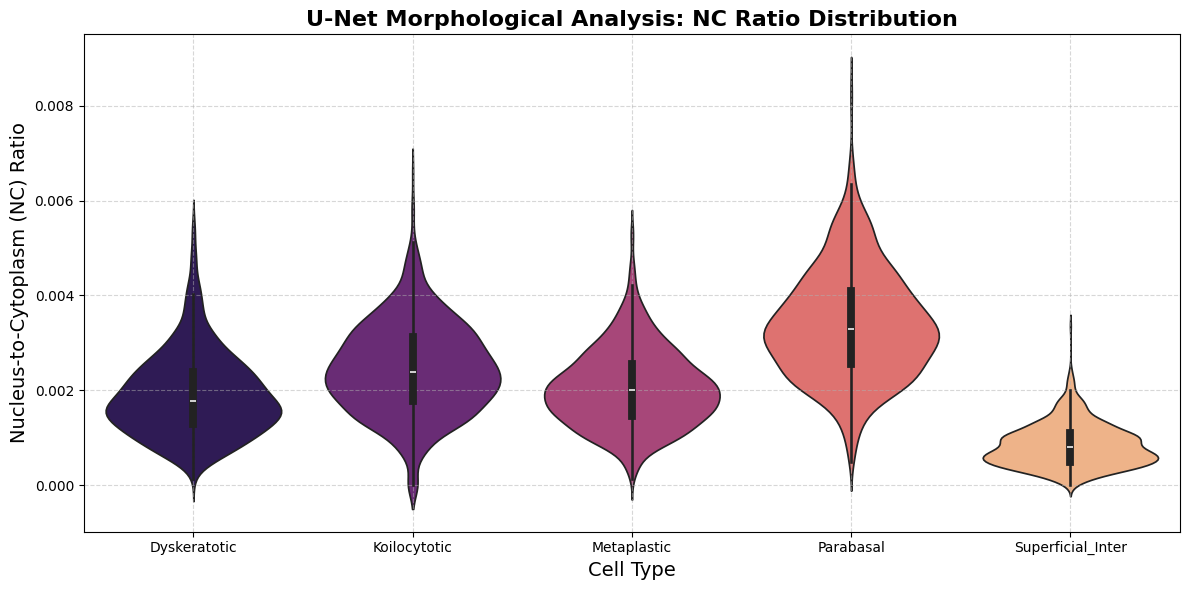

In [90]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Load the features you just extracted!
# df = pd.read_csv(r"..\processed_data\extracted_features.csv")
df = pd.read_csv(r"..\processed_data\extracted_features_enhanced.csv")

# Create a mapping dictionary to change Class IDs (0,1,2,3,4) back to text names
class_mapping = {
    0: 'Dyskeratotic',
    1: 'Koilocytotic',
    2: 'Metaplastic',
    3: 'Parabasal',
    4: 'Superficial_Inter'
}
df['Class_Name'] = df['True_Class'].map(class_mapping)

# 2. Draw the Violin Plot!
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='Class_Name', y='LBP_0', palette='magma')
plt.title('U-Net Morphological Analysis: NC Ratio Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Cell Type', fontsize=14)
plt.ylabel('Nucleus-to-Cytoplasm (NC) Ratio', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### Data Science Validation: Feature Correlation
To justify an ensemble approach (fusing U-Net and EfficientNet data), we must prove that the models are extracting distinct, non-overlapping information. 
This Correlation Heatmap maps the linear relationships between the physical measurements and the Deep AI probabilities. Low or inverse correlations between U-Net features (e.g., NC_Ratio) and EfficientNet features (e.g., Prob_1) mathematically prove that the models are complementary, ensuring our final XGBoost Meta-Learner receives a rich, multi-dimensional dataset.


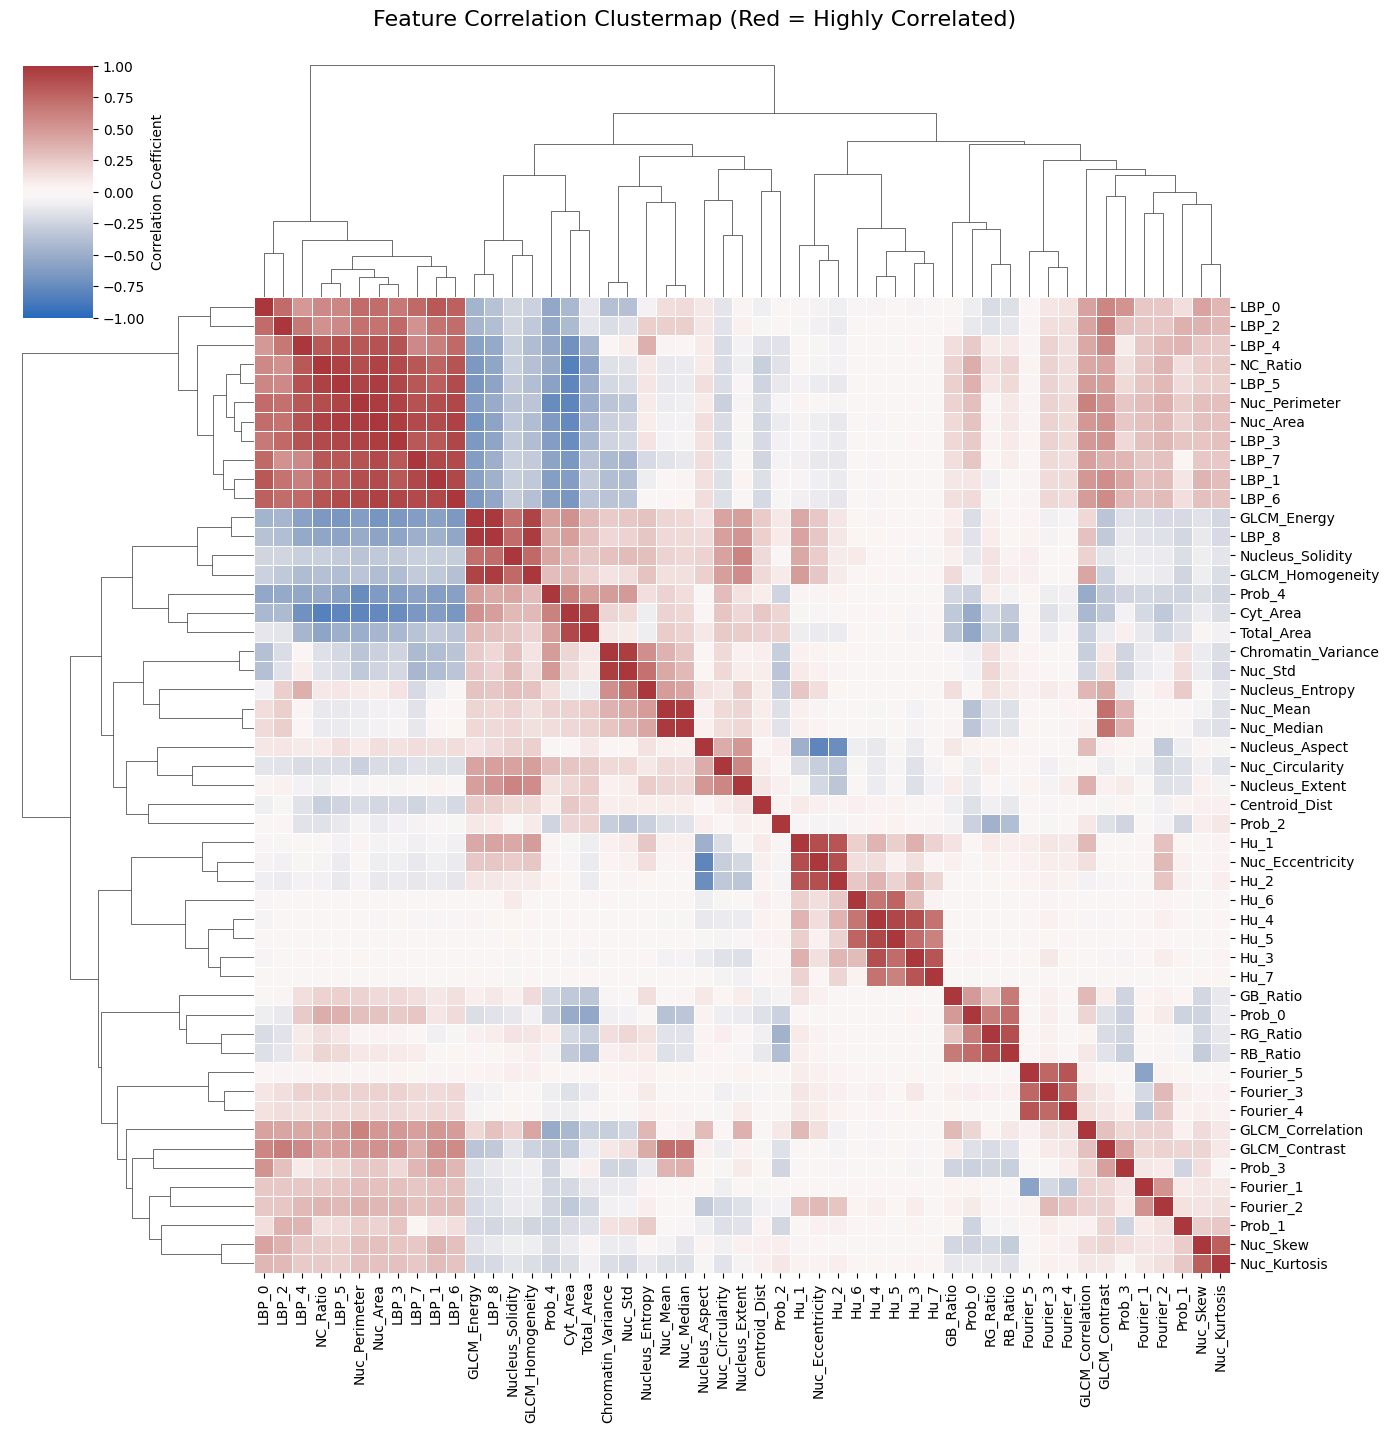

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate the correlation matrix for all features
corr_matrix = X.corr()

# 2. Create a Clustermap
# - 'cmap=vlag' gives a nice blue (negative) to red (positive) gradient
# - 'center=0' ensures that exactly 0 correlation is pure white
# - 'figsize' is large enough to read the feature names
heatmap = sns.clustermap(
    corr_matrix, 
    cmap="vlag", 
    center=0, 
    vmin=-1, 
    vmax=1,
    figsize=(14, 14),
    linewidths=0.5,
    cbar_kws={"shrink": .5, "label": "Correlation Coefficient"}
)

# 3. Add a clean title
heatmap.fig.suptitle('Feature Correlation Clustermap (Red = Highly Correlated)', y=1.02, fontsize=16)

plt.show()
